# Baseline models

This notebook compares a majority-class baseline with a class-weighted
logistic regression model.

The objective is to determine whether machine failures can be detected
better than by always predicting the majority class.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay

from predictive_maintenance.data import load_data
from predictive_maintenance.evaluate import calculate_metrics
from predictive_maintenance.features import create_features
from predictive_maintenance.train import (
    create_dummy_model,
    create_logistic_model,
    split_data,
)

In [2]:
df = load_data()
X, y = create_features(df)

X_train, X_test, y_train, y_test = split_data(X, y)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")
print(f"Failures in training data: {y_train.sum()}")
print(f"Failures in test data: {y_test.sum()}")

Loading local dataset from /Users/alexanderkorolev/Desktop/predictive-maintenance-ai4i/data/raw/ai4i2020.csv
Training observations: 8000
Test observations: 2000
Failures in training data: 271
Failures in test data: 68


In [3]:
dummy_model = create_dummy_model(X_train)
dummy_model.fit(X_train, y_train)

dummy_metrics = calculate_metrics(
    dummy_model,
    X_test,
    y_test,
)

dummy_metrics

{'accuracy': 0.966,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0,
 'pr_auc': 0.034}

In [4]:
logistic_model = create_logistic_model(X_train)
logistic_model.fit(X_train, y_train)

logistic_metrics = calculate_metrics(
    logistic_model,
    X_test,
    y_test,
)

logistic_metrics

{'accuracy': 0.8245,
 'precision': 0.14177215189873418,
 'recall': 0.8235294117647058,
 'f1_score': 0.24190064794816415,
 'pr_auc': 0.38176196610560775}

In [5]:
results = pd.DataFrame(
    [
        {"model": "Dummy classifier", **dummy_metrics},
        {"model": "Logistic regression", **logistic_metrics},
    ]
)

results.set_index("model").round(3)

,accuracy,precision,recall,f1_score,pr_auc
model,,,,,
Dummy classifier,0.966,0.000,0.000,0.000,0.034
Logistic regression,0.824,0.142,0.824,0.242,0.382


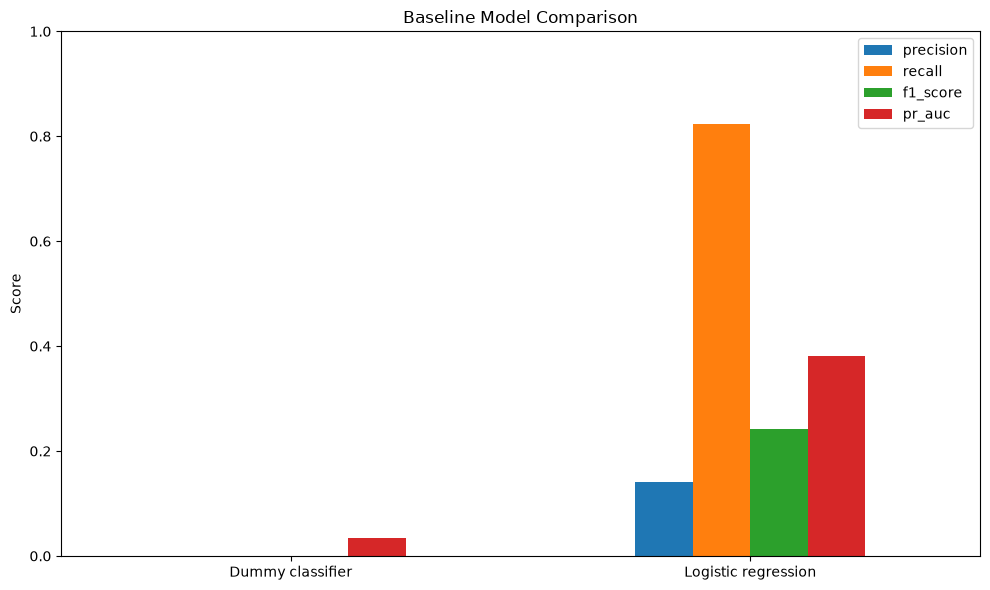

In [6]:
results_plot = results.set_index("model")[
    ["precision", "recall", "f1_score", "pr_auc"]
]

results_plot.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Interpretation

The dummy classifier is unable to detect any machine failures because it
always predicts the majority class. Therefore, its precision, recall, and
F1-score are zero.

The class-weighted logistic regression detects approximately 82% of the
machine failures. However, its low precision indicates that it also produces
many false alarms. Its PR-AUC is substantially higher than the baseline,
showing that the available machine features contain useful information for
failure prediction.

For predictive maintenance, a high recall can be valuable because an
undetected failure may be more costly than an unnecessary maintenance alert.
Nevertheless, the trade-off between detected failures and false alarms must
be considered.

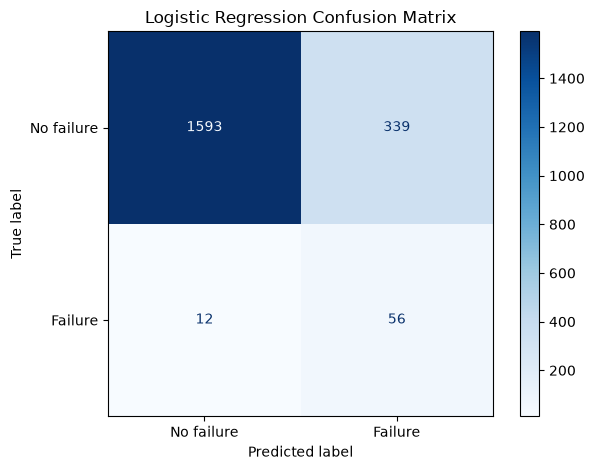

In [7]:
ConfusionMatrixDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test,
    display_labels=["No failure", "Failure"],
    cmap="Blues",
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

## Confusion matrix interpretation

The logistic regression correctly detects 56 of 68 machine failures, while
12 failures remain undetected. This corresponds to a recall of approximately
82.4%.

However, the model also generates 339 false alarms. Only approximately 14.2%
of all predicted failures are actual failures. The model therefore provides
high failure coverage but relatively low alarm reliability.

This result represents a useful baseline. Further models and threshold
optimization are required to reduce false alarms without overlooking too many
machine failures.